In [ ]:
!pip install roboflow

# Banana Classification using YOLO

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import glob
from collections import Counter
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from roboflow import Roboflow
# from kaggle_secrets import UserSecretsClient

from google.colab.patches import cv2_imshow
from google.colab import userdata

## Problem Definition

- Task: Image Classification
- Dataset: Banana Ripeness Classification
- Objective: Classify images into 6 classes:
  - freshripe, freshunripe, overripe, ripe, rotten, unripe

- Approach:
  - Fine-tune a pretrained EfficientNet model
  - Compare performance with YOLO classification

## Dataset + EDA

In [12]:
# user_secrets = UserSecretsClient()
# rf = Roboflow(api_key=user_secrets.get_secret("ROBOFLOW_API_KEY"))
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("chetan-sharma-n4cau").project("banana-ripeness-classification-a9hps")
version = project.version(3)
dataset = version.download("folder")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Banana-Ripeness-Classification-3 in folder:: 100%|██████████| 5639/5639 [00:00<00:00, 12206.47it/s]


In [22]:
data_dir = "./Banana-Ripeness-Classification-3"

train_dir = f"{data_dir}/train"
val_dir   = f"{data_dir}/valid"
test_dir  = f"{data_dir}/test"

In [24]:
def get_class_distribution(path):
    counter = Counter()

    train_path = os.path.join(path, "train")

    for cls in os.listdir(train_path):
        cls_path = os.path.join(train_path, cls)
        counter[cls] = len(os.listdir(cls_path))

    return counter

dist = get_class_distribution(data_dir)
print(dist)

Counter({'rotten': 1340, 'overripe': 783, 'freshripe': 704, 'freshunripe': 501, 'ripe': 470, 'unripe': 133})


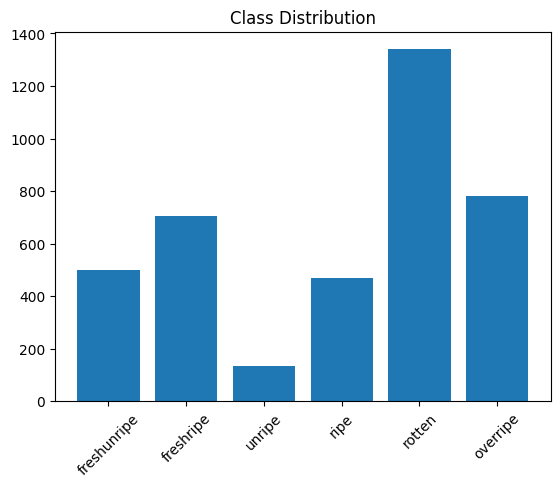

In [25]:
plt.bar(dist.keys(), dist.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

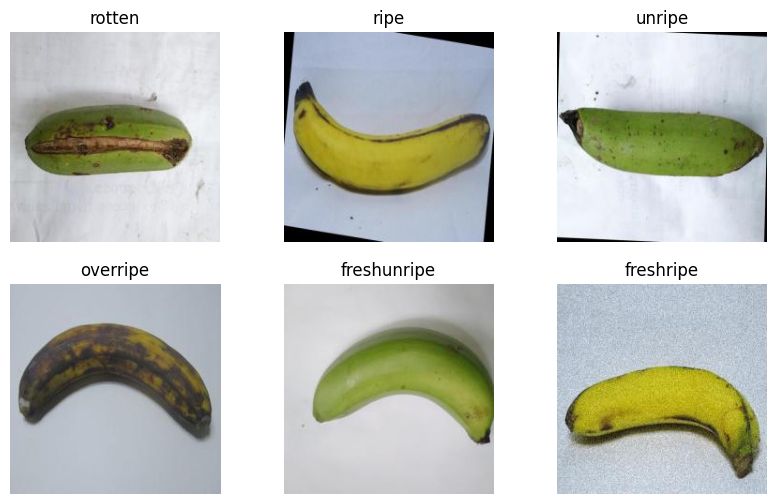

In [27]:
def show_samples(path, n=6):
    train_path = os.path.join(path, "train")

    classes = os.listdir(train_path)

    plt.figure(figsize=(10,6))

    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(train_path, cls)))
        img_path = os.path.join(train_path, cls, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

    plt.show()

show_samples(data_dir)

### EDA Findings
- **Dataset Split:**
  - Training set: 7057 images and 7057 labels.
  - Validation set: 2048 images and 2048 labels.
  - Test set: 1020 images and 1020 labels.
- **Class Distribution:** The dataset contains a single class (class `0`) with 7357 instances across the training set, therefore it's a single-object detection task (i.e., license plates).
- **Bounding Box Dimensions:**
  - Average normalized width of bounding boxes: ~0.20
  - Average normalized height of bounding boxes: ~0.15
- **Data Integrity:**
  - No missing label files were found for the images.
  - 5 empty label files were identified, meaning 5 images in the training set do not have any annotations.

## Preprocessing + Augmentation
- auto scaling done in robo flow
- images are resized to 640*640 in roboflow

#### Transform

In [28]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#### Data Loader

In [29]:
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir, transform=val_transform)
test_data  = datasets.ImageFolder(test_dir, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

class_names = train_data.classes
print(class_names)

['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']


## Model + Config

- Model: EfficientNet

>- Using pretrained EfficientNet-B0
>- Replacing final classification layer
>- Transfer learning for faster convergence

In [35]:
model = models.efficientnet_b0(pretrained=True)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

## Training

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [37]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss:.4f}")

Epoch 1/10, Loss: 41.3782
Epoch 2/10, Loss: 21.2852
Epoch 3/10, Loss: 14.9327
Epoch 4/10, Loss: 10.7259
Epoch 5/10, Loss: 10.9815
Epoch 6/10, Loss: 11.2840
Epoch 7/10, Loss: 8.5448
Epoch 8/10, Loss: 9.1647
Epoch 9/10, Loss: 7.4374
Epoch 10/10, Loss: 6.0910


## Evaluation

- Metric: Accuracy
- Evaluate on validation set

In [38]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
print("Validation Accuracy:", acc)

Validation Accuracy: 0.9679430097951914


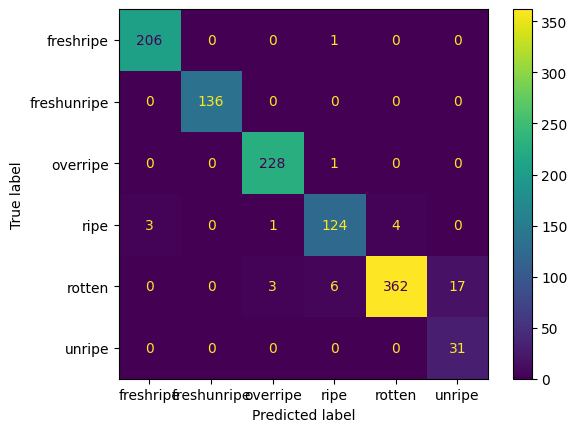

In [39]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot()

### visualization

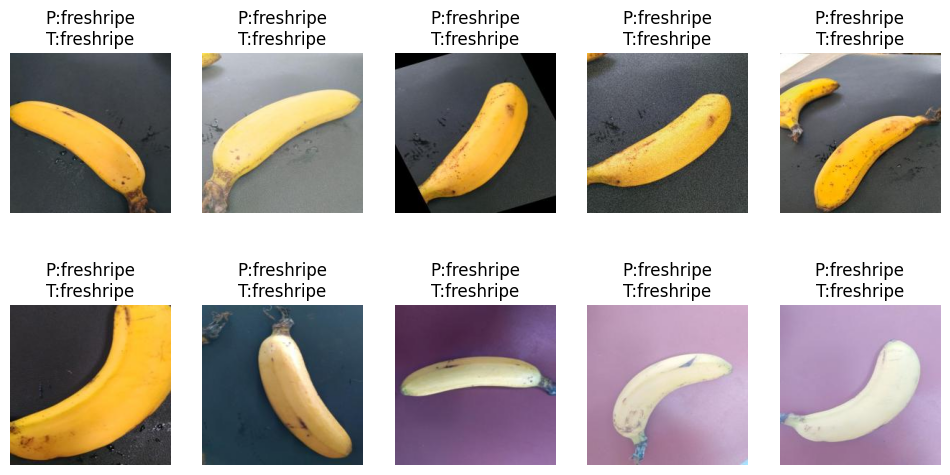

In [40]:
images, labels = next(iter(test_loader))

model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.argmax(outputs, dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1,2,0)
    ax.imshow(img)
    ax.set_title(f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}")
    ax.axis("off")

plt.show()

## Model Testing

In [41]:
model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        test_preds.extend(preds)
        test_labels.extend(labels.numpy())

test_acc = accuracy_score(test_labels, test_preds)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9715302491103203


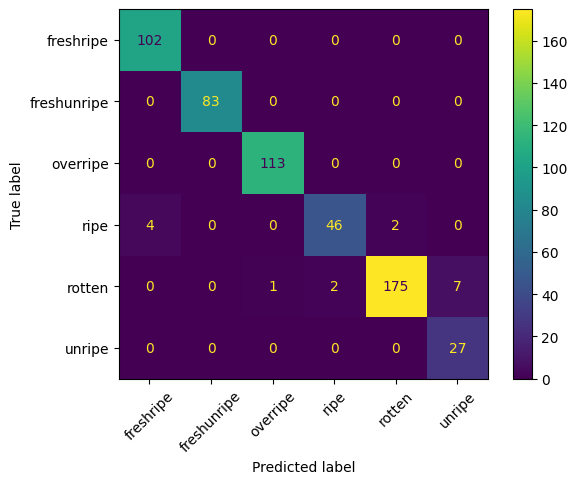

In [42]:
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(xticks_rotation=45)

In [43]:
print(classification_report(test_labels, test_preds, target_names=class_names))

              precision    recall  f1-score   support

   freshripe       0.96      1.00      0.98       102
 freshunripe       1.00      1.00      1.00        83
    overripe       0.99      1.00      1.00       113
        ripe       0.96      0.88      0.92        52
      rotten       0.99      0.95      0.97       185
      unripe       0.79      1.00      0.89        27

    accuracy                           0.97       562
   macro avg       0.95      0.97      0.96       562
weighted avg       0.97      0.97      0.97       562



### model saving

In [44]:
torch.save(model.state_dict(), "efficientnet_banana.pth")

## Conclusion

*   **Task:** Image Classification for Banana Ripeness
*   **Objective:** Classify images into 6 classes (freshripe, freshunripe, overripe, ripe, rotten, unripe).
*   **Approach:** Fine-tuned a pretrained EfficientNet model.
*   **Validation Accuracy:** `0.9679` (approximately 96.8%)
*   **Test Accuracy:** `0.9715` (approximately 97.2%)